# Optimal Stopping
We have to perform N-1 neural networks to decide what the value is over the whole time period 

## Simulate Paths

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [110]:
class UnivariateEulerMethods:
    """Euler methods for univariate asset price simulations"""
    
    def __init__(self, T, n_steps, n_paths, X0, mu, sigma):
        """
        Initialize simulation parameters
        
        Args:
            T: Time horizon
            n_steps: Number of time steps
            n_paths: Number of simulation paths
            X0: Initial asset price
            mu: Drift
            sigma: Volatility
        """
        self.T = T
        self.n_steps = n_steps
        self.dt = T / n_steps
        self.n_paths = n_paths
        self.X0 = X0
        self.mu = mu
        self.sigma = sigma
    
    def gbm(self):
        """Geometric Brownian Motion"""
        X_t = np.zeros((self.n_steps + 1, self.n_paths))
        X_t[0, :] = self.X0
        
        Z = np.random.normal(0.0, 1.0, (self.n_steps, self.n_paths))
        
        for k in range(self.n_steps):
            X_t[k+1, :] = X_t[k, :] * np.exp(
                (self.mu - 0.5*self.sigma**2)*self.dt + 
                self.sigma*np.sqrt(self.dt)*Z[k, :]
            )
        
        return X_t
    
    def gbm_with_jumps(self, lambda_jumps, mu_j, sigma_j):
        """
        GBM with Poisson jumps
        
        Args:
            lambda_jumps: Jump intensity (expected jumps per year)
            mu_j: Mean log-jump size
            sigma_j: Volatility of log-jump size
        """
        X_t = np.zeros((self.n_steps + 1, self.n_paths))
        X_t[0, :] = self.X0
        
        Z = np.random.normal(0.0, 1.0, (self.n_steps, self.n_paths))
        N = np.random.poisson(lambda_jumps * self.dt, (self.n_steps, self.n_paths))
        J = np.random.normal(mu_j, sigma_j, (self.n_steps, self.n_paths))
        
        for k in range(self.n_steps):
            diffusion = X_t[k, :] * np.exp(
                (self.mu - 0.5*self.sigma**2)*self.dt + 
                self.sigma*np.sqrt(self.dt)*Z[k, :]
            )
            jump_multiplier = np.exp(J[k, :] * N[k, :])
            X_t[k+1, :] = diffusion * jump_multiplier
        
        return X_t
    
    def gbm_with_hawkes(self, alpha, beta, mu_j, sigma_j):
        """
        GBM with self-exciting Hawkes jumps
        
        Args:
            alpha: Hawkes self-excitement parameter
            beta: Hawkes mean reversion rate
            mu_j: Mean log-jump size
            sigma_j: Volatility of log-jump size
        """
        X_t = np.zeros((self.n_steps + 1, self.n_paths))
        X_t[0, :] = self.X0
        lambda_t = np.ones((self.n_steps + 1, self.n_paths))
        
        Z = np.random.normal(0.0, 1.0, (self.n_steps, self.n_paths))
        J = np.random.normal(mu_j, sigma_j, (self.n_steps, self.n_paths))
        
        for k in range(self.n_steps):
            N = np.random.poisson(lambda_t[k, :] * self.dt)
            
            lambda_t[k+1, :] = lambda_t[k, :] * np.exp(-beta * self.dt) + alpha * N
            lambda_t[k+1, :] = np.maximum(lambda_t[k+1, :], 0.01)
            
            diffusion = X_t[k, :] * np.exp(
                (self.mu - 0.5*self.sigma**2)*self.dt + 
                self.sigma*np.sqrt(self.dt)*Z[k, :]
            )
            jump_multiplier = np.exp(J[k, :] * N)
            X_t[k+1, :] = diffusion * jump_multiplier
        
        return X_t, lambda_t
    
    def gbm_with_stochastic_vol(self, kappa, theta, xi):
        """
        GBM with stochastic volatility (CIR-type)
        
        Args:
            kappa: Mean reversion speed of volatility
            theta: Long-term mean volatility
            xi: Volatility of volatility
        """
        X_t = np.zeros((self.n_steps + 1, self.n_paths))
        V_t = np.zeros((self.n_steps + 1, self.n_paths))
        X_t[0, :] = self.X0
        V_t[0, :] = self.sigma**2
        
        Z_x = np.random.normal(0.0, 1.0, (self.n_steps, self.n_paths))
        Z_v = np.random.normal(0.0, 1.0, (self.n_steps, self.n_paths))
        
        rho = -0.5
        Z_v_adjusted = rho * Z_x + np.sqrt(1 - rho**2) * Z_v
        
        for k in range(self.n_steps):
            V_t[k+1, :] = V_t[k, :] + kappa * (theta - V_t[k, :]) * self.dt + \
                          xi * np.sqrt(V_t[k, :] * self.dt) * Z_v_adjusted[k, :]
            V_t[k+1, :] = np.maximum(V_t[k+1, :], 1e-4)
            
            X_t[k+1, :] = X_t[k, :] * np.exp(
                (self.mu - 0.5*V_t[k+1, :])*self.dt + 
                np.sqrt(V_t[k+1, :]*self.dt)*Z_x[k, :]
            )
        
        return X_t, V_t

In [111]:
# generate Euler method
n_paths = 10000
n_steps = 100
T = 1
dt = T / n_steps
mu = 0.05
sigma = 0.2
X0 = 100

lambda_jumps = 1.0  # jump intensity (expected # jumps per year)
mu_j = -0.1  # mean log-jump size
sigma_j = 0.3  # volatility of log-jump size

In [112]:
euler_sim = UnivariateEulerMethods(T=1, n_steps=100, n_paths=1000, X0=100, mu=0.05, sigma=0.2)

# 1. Standard GBM
X_gbm = euler_sim.gbm()

# 2. GBM with Poisson jumps
X_jumps = euler_sim.gbm_with_jumps(lambda_jumps=1.0, mu_j=-0.1, sigma_j=0.3)

# 3. GBM with Hawkes jumps
X_hawkes, lambda_hawkes = euler_sim.gbm_with_hawkes(alpha=0.5, beta=2.0, mu_j=-0.1, sigma_j=0.3)

# 4. GBM with stochastic volatility
X_stoch_vol, V_t = euler_sim.gbm_with_stochastic_vol(kappa=2.0, theta=0.04, xi=0.1)

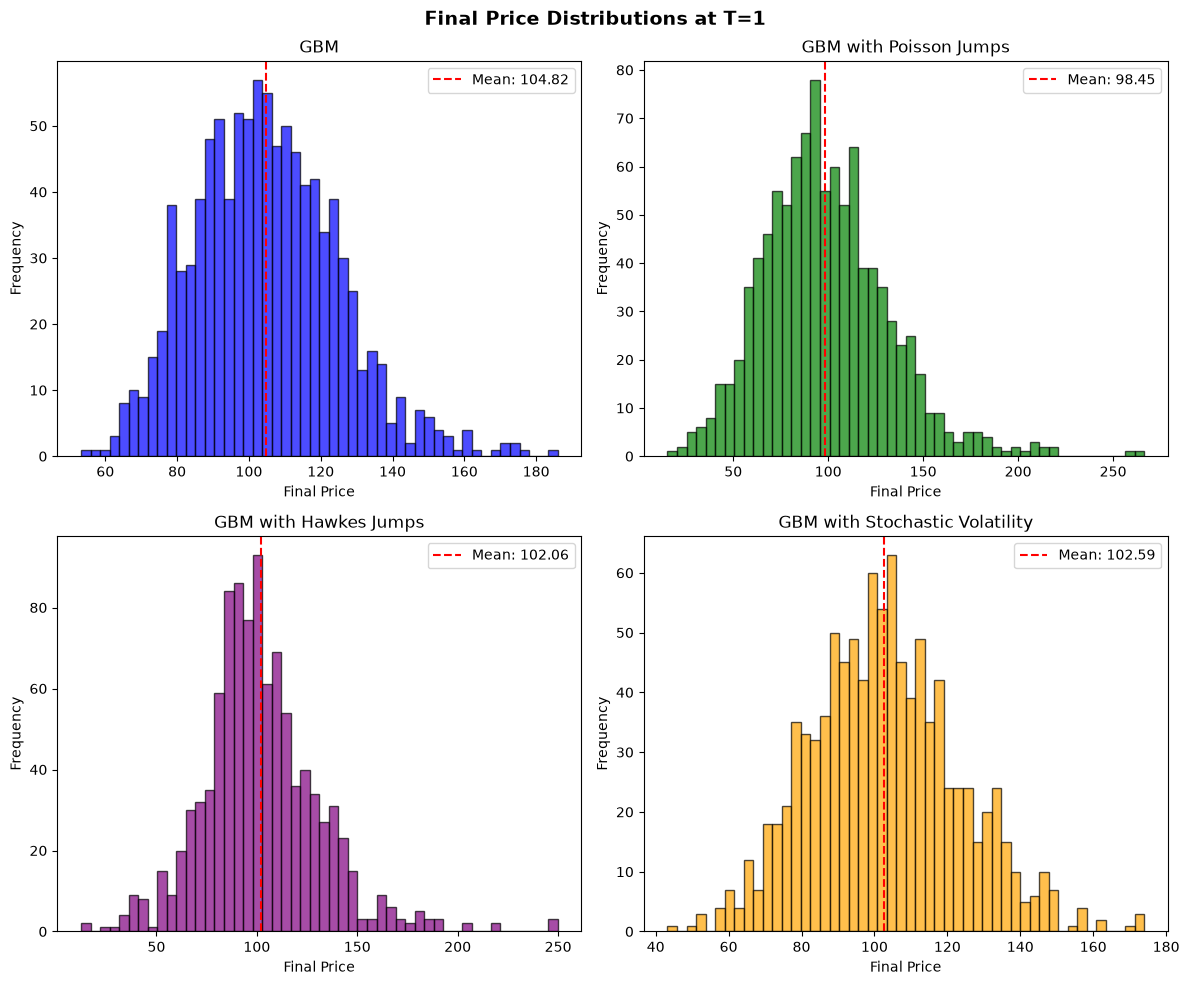

Summary Statistics:
GBM: mean=104.8244, std=19.9983, min=53.2229, max=185.9876
GBM+Jumps: mean=98.4533, std=33.1365, min=15.3729, max=266.3273
GBM+Hawkes: mean=102.0575, std=28.9032, min=12.4402, max=249.7616
GBM+StocVol: mean=102.5937, std=20.3700, min=43.2338, max=173.9609


In [113]:
# Plot final distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Final Price Distributions at T=1', fontsize=14, fontweight='bold')

# GBM
ax = axes[0, 0]
ax.hist(X_gbm[-1, :], bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.set_title('GBM')
ax.set_xlabel('Final Price')
ax.set_ylabel('Frequency')
ax.axvline(np.mean(X_gbm[-1, :]), color='red', linestyle='--', label=f'Mean: {np.mean(X_gbm[-1, :]):.2f}')
ax.legend()

# GBM with Jumps
ax = axes[0, 1]
ax.hist(X_jumps[-1, :], bins=50, alpha=0.7, color='green', edgecolor='black')
ax.set_title('GBM with Poisson Jumps')
ax.set_xlabel('Final Price')
ax.set_ylabel('Frequency')
ax.axvline(np.mean(X_jumps[-1, :]), color='red', linestyle='--', label=f'Mean: {np.mean(X_jumps[-1, :]):.2f}')
ax.legend()

# GBM with Hawkes
ax = axes[1, 0]
ax.hist(X_hawkes[-1, :], bins=50, alpha=0.7, color='purple', edgecolor='black')
ax.set_title('GBM with Hawkes Jumps')
ax.set_xlabel('Final Price')
ax.set_ylabel('Frequency')
ax.axvline(np.mean(X_hawkes[-1, :]), color='red', linestyle='--', label=f'Mean: {np.mean(X_hawkes[-1, :]):.2f}')
ax.legend()

# GBM with Stochastic Vol
ax = axes[1, 1]
ax.hist(X_stoch_vol[-1, :], bins=50, alpha=0.7, color='orange', edgecolor='black')
ax.set_title('GBM with Stochastic Volatility')
ax.set_xlabel('Final Price')
ax.set_ylabel('Frequency')
ax.axvline(np.mean(X_stoch_vol[-1, :]), color='red', linestyle='--', label=f'Mean: {np.mean(X_stoch_vol[-1, :]):.2f}')
ax.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
print(f"GBM: mean={np.mean(X_gbm[-1, :]):.4f}, std={np.std(X_gbm[-1, :]):.4f}, min={np.min(X_gbm[-1, :]):.4f}, max={np.max(X_gbm[-1, :]):.4f}")
print(f"GBM+Jumps: mean={np.mean(X_jumps[-1, :]):.4f}, std={np.std(X_jumps[-1, :]):.4f}, min={np.min(X_jumps[-1, :]):.4f}, max={np.max(X_jumps[-1, :]):.4f}")
print(f"GBM+Hawkes: mean={np.mean(X_hawkes[-1, :]):.4f}, std={np.std(X_hawkes[-1, :]):.4f}, min={np.min(X_hawkes[-1, :]):.4f}, max={np.max(X_hawkes[-1, :]):.4f}")
print(f"GBM+StocVol: mean={np.mean(X_stoch_vol[-1, :]):.4f}, std={np.std(X_stoch_vol[-1, :]):.4f}, min={np.min(X_stoch_vol[-1, :]):.4f}, max={np.max(X_stoch_vol[-1, :]):.4f}")

## Calculate Reward
We will be looking at call options on the classic GBM price

In [114]:
K = 100
def intrinsic_value(S,K):
    return np.maximum(K - S, 0)
american_values = intrinsic_value(X_gbm,K)

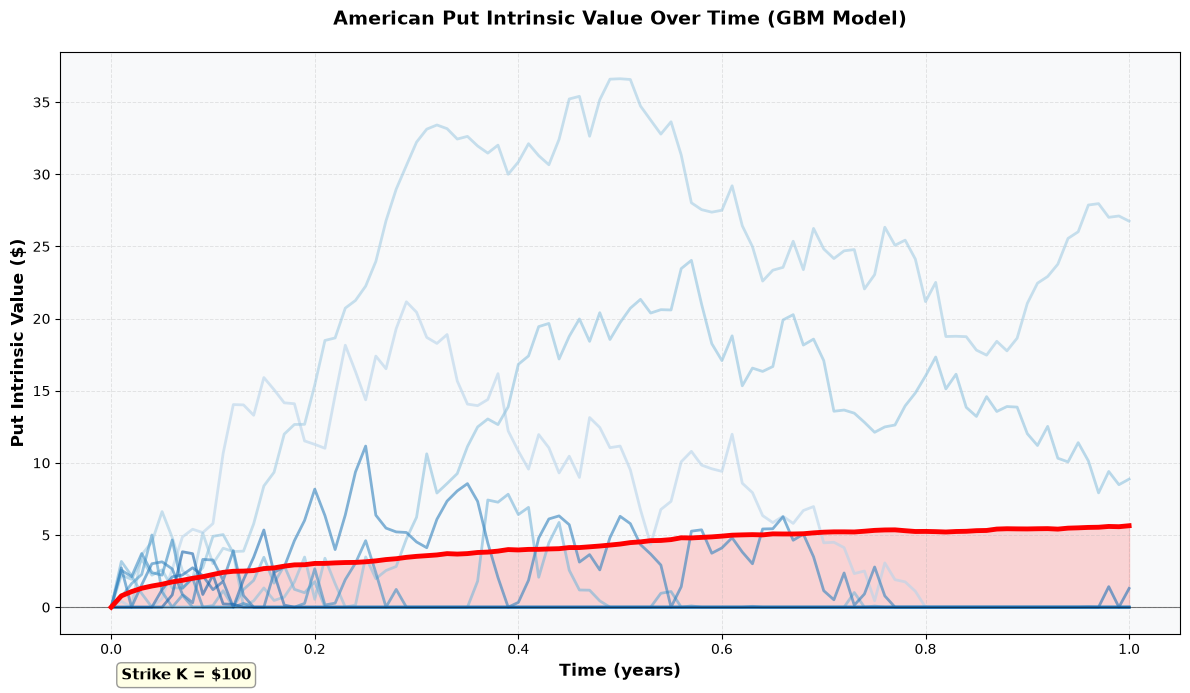


Intrinsic Value Statistics:
At t=0: Mean = $0.00
At t=T: Mean = $5.64
Max mean intrinsic value: $5.64 at t=1.000


In [115]:
# Visualize intrinsic values through time for GBM
time_grid = np.linspace(0, 1, X_gbm.shape[0])

# Select 10 random paths
np.random.seed(42)
sample_paths = np.random.choice(X_gbm.shape[1], size=10, replace=False)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot 10 individual paths with nice colors
colors = plt.cm.Blues(np.linspace(0.3, 0.8, 10))
for i, path_idx in enumerate(sample_paths):
    ax.plot(time_grid, american_values[:, path_idx], 
            color=colors[i], alpha=0.6, linewidth=2)

# Plot mean intrinsic value
mean_intrinsic = np.mean(american_values, axis=1)
ax.plot(time_grid, mean_intrinsic, 
        color='red', linewidth=3.5, label='Mean Intrinsic Value', zorder=5)

# Fill area between mean and zero
ax.fill_between(time_grid, 0, mean_intrinsic, alpha=0.15, color='red')

# Styling
ax.set_xlabel('Time (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Put Intrinsic Value ($)', fontsize=12, fontweight='bold')
ax.set_title('American Put Intrinsic Value Over Time (GBM Model)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Add strike price annotation
ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
ax.text(0.01, -5, f'Strike K = ${K}', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, edgecolor='gray'))

# Set background
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

print(f"\nIntrinsic Value Statistics:")
print(f"At t=0: Mean = ${mean_intrinsic[0]:.2f}")
print(f"At t=T: Mean = ${mean_intrinsic[-1]:.2f}")
print(f"Max mean intrinsic value: ${np.max(mean_intrinsic):.2f} at t={time_grid[np.argmax(mean_intrinsic)]:.3f}")

In [116]:
import math
import time

import torch
import torch.nn as nn


class StoppingNetwork(nn.Module):
    """F^theta: R^{d+1} -> (0,1); depth I=3, ReLU hidden layers, batch norm, Xavier init (Section 2.2, 4.1)."""

    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, y):
        # returns the logit; F = sigmoid(logit), f = 1{logit >= 0}
        return self.net(y).squeeze(-1)


class DeepOptimalStopping:
    """
    Becker, Cheridito & Jentzen (2020), Deep optimal stopping.

    step(x, n) -> x_{n+1}: one-step Markov transition, x has shape (m, d).
    payoff(x) -> (m,): undiscounted exercise value; g(n, x) = exp(-r t_n) * payoff(x).
    """

    def __init__(self, step, payoff, x0, N, T, r, device="cpu"):
        self.step = step
        self.payoff = payoff
        self.device = device
        self.x0 = torch.as_tensor(x0, dtype=torch.float32, device=device).reshape(1, -1)
        self.d = self.x0.shape[1]
        self.N = N
        self.T = T
        self.r = r
        self.dt = T / N
        # f^{theta_n} for n = 1..N-1 lives at networks[n-1]; f_N == 1; f_0 is a constant (Remark 6)
        self.networks = nn.ModuleList(
            [StoppingNetwork(self.d + 1, self.d + 40) for _ in range(N - 1)]
        ).to(device)
        self.f0 = None

    def g(self, n, x):
        return math.exp(-self.r * n * self.dt) * self.payoff(x)

    def features(self, n, x):
        # Y_n = (X_n, g(n, X_n)) as in Section 4.1
        return torch.cat([x, self.g(n, x).unsqueeze(-1)], dim=-1)

    def simulate(self, n_paths):
        x = self.x0.expand(n_paths, self.d).clone()
        paths = [x]
        for n in range(self.N):
            x = self.step(x, n)
            paths.append(x)
        return torch.stack(paths, dim=1)

    @torch.no_grad()
    def stop_decision(self, n, x):
        """Hard decision f^{theta_n}(x) in {0,1} (eq. 8): 1 iff logit >= 0, i.e. F >= 1/2."""
        if n == self.N:
            return torch.ones(x.shape[0], dtype=torch.bool, device=self.device)
        if n == 0:
            return torch.full((x.shape[0],), bool(self.f0), device=self.device)
        return self.networks[n - 1](self.features(n, x)) >= 0

    def train(self, n_paths=2**16, batch_size=8192, steps_per_date=300, lr=1e-3, verbose=True):
        """Backward induction of Section 2.3: maximise mean r_n^k(theta) for n = N-1, ..., 1."""
        start = time.time()
        with torch.no_grad():
            x = self.simulate(n_paths)
            g_all = torch.stack([self.g(n, x[:, n]) for n in range(self.N + 1)], dim=1)

        # reward at tau_{n+1} along each training path, starting from tau_N = N
        g_tau = g_all[:, self.N].clone()

        for n in range(self.N - 1, 0, -1):
            net = self.networks[n - 1]
            net.train()
            optimizer = torch.optim.Adam(net.parameters(), lr=lr)
            y_n = self.features(n, x[:, n])
            g_n = g_all[:, n]

            for _ in range(steps_per_date):
                idx = torch.randint(0, n_paths, (batch_size,), device=self.device)
                F = torch.sigmoid(net(y_n[idx]))
                # r_n^k(theta) = g(n, x_n) F(x_n) + g(l_{n+1}, x_{l_{n+1}}) (1 - F(x_n))
                reward = g_n[idx] * F + g_tau[idx] * (1 - F)
                loss = -reward.mean()
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            net.eval()
            # tau_n = n f_n(X_n) + tau_{n+1} (1 - f_n(X_n)) with the hard decision
            stop = self.stop_decision(n, x[:, n])
            g_tau = torch.where(stop, g_n, g_tau)

            if verbose and (n % 10 == 0 or n == 1):
                print(f"n={n:3d}  E[g(tau_n, X_tau_n)] = {g_tau.mean().item():.4f}  "
                      f"stop now: {stop.float().mean().item():.1%}  ({time.time() - start:.0f}s)")

        # Remark 6: stop at 0 iff g(0, x0) >= C_hat = E g(tau_1, X_tau_1)
        self.f0 = bool(self.g(0, self.x0).item() >= g_tau.mean().item())
        if verbose:
            print(f"f_0 = {int(self.f0)}  (g(0,x0) = {self.g(0, self.x0).item():.4f}, "
                  f"C_hat = {g_tau.mean().item():.4f})")

    @torch.no_grad()
    def _policy_reward(self, x, n_start):
        """g(tau, X_tau) for tau = tau_{n_start+1} along fresh paths started from state x at time n_start."""
        m = x.shape[0]
        reward = torch.zeros(m, device=self.device)
        alive = torch.ones(m, dtype=torch.bool, device=self.device)
        for n in range(n_start + 1, self.N + 1):
            x = self.step(x, n - 1)
            stop = alive & self.stop_decision(n, x)
            reward = torch.where(stop, self.g(n, x), reward)
            alive &= ~stop
            if not alive.any():
                break
        return reward

    @torch.no_grad()
    def stopping_times(self, paths):
        """tau^Theta (eq. 14 with f_0) and g(tau, X_tau) along given paths of shape (m, N+1, d)."""
        m = paths.shape[0]
        reward = torch.zeros(m, device=self.device)
        tau = torch.full((m,), self.N, device=self.device)
        alive = torch.ones(m, dtype=torch.bool, device=self.device)
        for n in range(self.N + 1):
            stop = alive & self.stop_decision(n, paths[:, n])
            reward = torch.where(stop, self.g(n, paths[:, n]), reward)
            tau = torch.where(stop, torch.full_like(tau, n), tau)
            alive &= ~stop
        return tau, reward

    @torch.no_grad()
    def lower_bound(self, n_paths=2**20, chunk=2**17):
        """Section 3.1: L_hat on paths independent of the training set."""
        rewards = []
        for i in range(0, n_paths, chunk):
            m = min(chunk, n_paths - i)
            if self.f0:
                rewards.append(self.g(0, self.x0).expand(m))
            else:
                rewards.append(self._policy_reward(self.x0.expand(m, self.d).clone(), 0))
        rewards = torch.cat(rewards)
        return rewards.mean().item(), rewards.std().item(), n_paths

    @torch.no_grad()
    def upper_bound(self, n_outer=1024, n_inner=512, verbose=True):
        """Section 3.2: dual upper bound with J = n_inner nested continuation paths per state."""
        start = time.time()
        z = self.simulate(n_outer)
        g_z = torch.stack([self.g(n, z[:, n]) for n in range(self.N + 1)], dim=1)

        # C_n^k = (1/J) sum_j g(tau_{n+1}^{k,j}, z~^{k,j}), n = 0..N-1
        C = torch.zeros(n_outer, self.N, device=self.device)
        for n in range(self.N):
            x = z[:, n].repeat_interleave(n_inner, dim=0)
            C[:, n] = self._policy_reward(x, n).view(n_outer, n_inner).mean(dim=1)
            if verbose and n % 20 == 0:
                print(f"  continuation values n={n:3d}/{self.N}  ({time.time() - start:.0f}s)")

        # Delta M_n = f_n g(n, z_n) + (1 - f_n) C_n - C_{n-1}; C_N is never used since f_N == 1
        M = torch.zeros(n_outer, self.N + 1, device=self.device)
        for n in range(1, self.N + 1):
            f = self.stop_decision(n, z[:, n]).float()
            C_n = C[:, n] if n < self.N else torch.zeros(n_outer, device=self.device)
            M[:, n] = M[:, n - 1] + f * g_z[:, n] + (1 - f) * C_n - C[:, n - 1]

        U_k = (g_z - M).max(dim=1).values
        return U_k.mean().item(), U_k.std().item(), n_outer

    def price(self, n_lower=2**20, n_outer=1024, n_inner=512, z=1.96, verbose=True):
        """Section 3.3: point estimate (L+U)/2 and asymptotic 95% confidence interval (eq. 19)."""
        L, sL, KL = self.lower_bound(n_lower)
        U, sU, KU = self.upper_bound(n_outer, n_inner, verbose=verbose)
        return {
            "lower": L,
            "upper": U,
            "point": 0.5 * (L + U),
            "ci": (L - z * sL / math.sqrt(KL), U + z * sU / math.sqrt(KU)),
        }

    @torch.no_grad()
    def exercise_probability(self, n, x):
        """Soft stopping probability F^{theta_n}(x), for plotting."""
        return torch.sigmoid(self.networks[n - 1](self.features(n, x)))

In [117]:
# American put under risk-neutral GBM, priced with deep optimal stopping
torch.manual_seed(0)
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.2, 1.0
N = n_steps  # exercise dates t_n = n T / N
dt_ex = T / N


def gbm_step(x, n):
    z = torch.randn_like(x)
    return x * torch.exp((r - 0.5 * sigma**2) * dt_ex + sigma * math.sqrt(dt_ex) * z)


def put_payoff(x):
    return torch.clamp(K - x[:, 0], min=0.0)


dos = DeepOptimalStopping(gbm_step, put_payoff, x0=[S0], N=N, T=T, r=r)

print("Training stopping decisions (backward induction)...")
dos.train(n_paths=2**16, batch_size=8192, steps_per_date=300)

print("\nEstimating lower bound, upper bound and confidence interval...")
result = dos.price(n_lower=2**20, n_outer=512, n_inner=256)

print(f"\nLower bound L_hat : {result['lower']:.4f}")
print(f"Upper bound U_hat : {result['upper']:.4f}")
print(f"Point estimate    : {result['point']:.4f}")
print(f"95% CI            : [{result['ci'][0]:.4f}, {result['ci'][1]:.4f}]")

Training stopping decisions (backward induction)...
n= 90  E[g(tau_n, X_tau_n)] = 5.7128  stop now: 41.0%  (12s)
n= 80  E[g(tau_n, X_tau_n)] = 5.8217  stop now: 31.1%  (23s)
n= 70  E[g(tau_n, X_tau_n)] = 5.9024  stop now: 21.6%  (33s)
n= 60  E[g(tau_n, X_tau_n)] = 5.9750  stop now: 17.7%  (44s)
n= 50  E[g(tau_n, X_tau_n)] = 6.0226  stop now: 12.1%  (61s)
n= 40  E[g(tau_n, X_tau_n)] = 6.0646  stop now: 9.5%  (77s)
n= 30  E[g(tau_n, X_tau_n)] = 6.0868  stop now: 4.9%  (93s)
n= 20  E[g(tau_n, X_tau_n)] = 6.0948  stop now: 1.3%  (109s)
n= 10  E[g(tau_n, X_tau_n)] = 6.0969  stop now: 0.0%  (127s)
n=  1  E[g(tau_n, X_tau_n)] = 6.0968  stop now: 0.0%  (142s)
f_0 = 0  (g(0,x0) = 0.0000, C_hat = 6.0968)

Estimating lower bound, upper bound and confidence interval...
  continuation values n=  0/100  (2s)
  continuation values n= 20/100  (36s)
  continuation values n= 40/100  (64s)
  continuation values n= 60/100  (79s)
  continuation values n= 80/100  (87s)

Lower bound L_hat : 6.0564
Upper boun

/var/folders/mc/w44dg5095cd1035wq8jxnqy80000gn/T/ipykernel_52780/3028817847.py:28: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(s[itm], cash[itm], degree)
/var/folders/mc/w44dg5095cd1035wq8jxnqy80000gn/T/ipykernel_52780/3028817847.py:28: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(s[itm], cash[itm], degree)
/var/folders/mc/w44dg5095cd1035wq8jxnqy80000gn/T/ipykernel_52780/3028817847.py:28: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(s[itm], cash[itm], degree)
/var/folders/mc/w44dg5095cd1035wq8jxnqy80000gn/T/ipykernel_52780/3028817847.py:28: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(s[itm], cash[itm], degree)
/var/folders/mc/w44dg5095cd1035wq8jxnqy80000gn/T/ipykernel_52780/3028817847.py:28: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(s[itm], cash[itm], degree)
/var/folders/mc/w44dg5095cd1035wq8jxnqy80000gn/T/ipykernel_52780/3028817847.py:28: RankWarning: Polyfit may be poor

Method                                   Price
------------------------------------------------------------
Deep OS lower bound L_hat               6.0564
Deep OS upper bound U_hat               6.2688
Deep OS point estimate                  6.1626
Deep OS 95% CI                        [6.0431, 6.3120]
Longstaff-Schwartz                      3.3620
Binomial Bermudan (100 dates)           6.0842
Binomial American                       6.0902


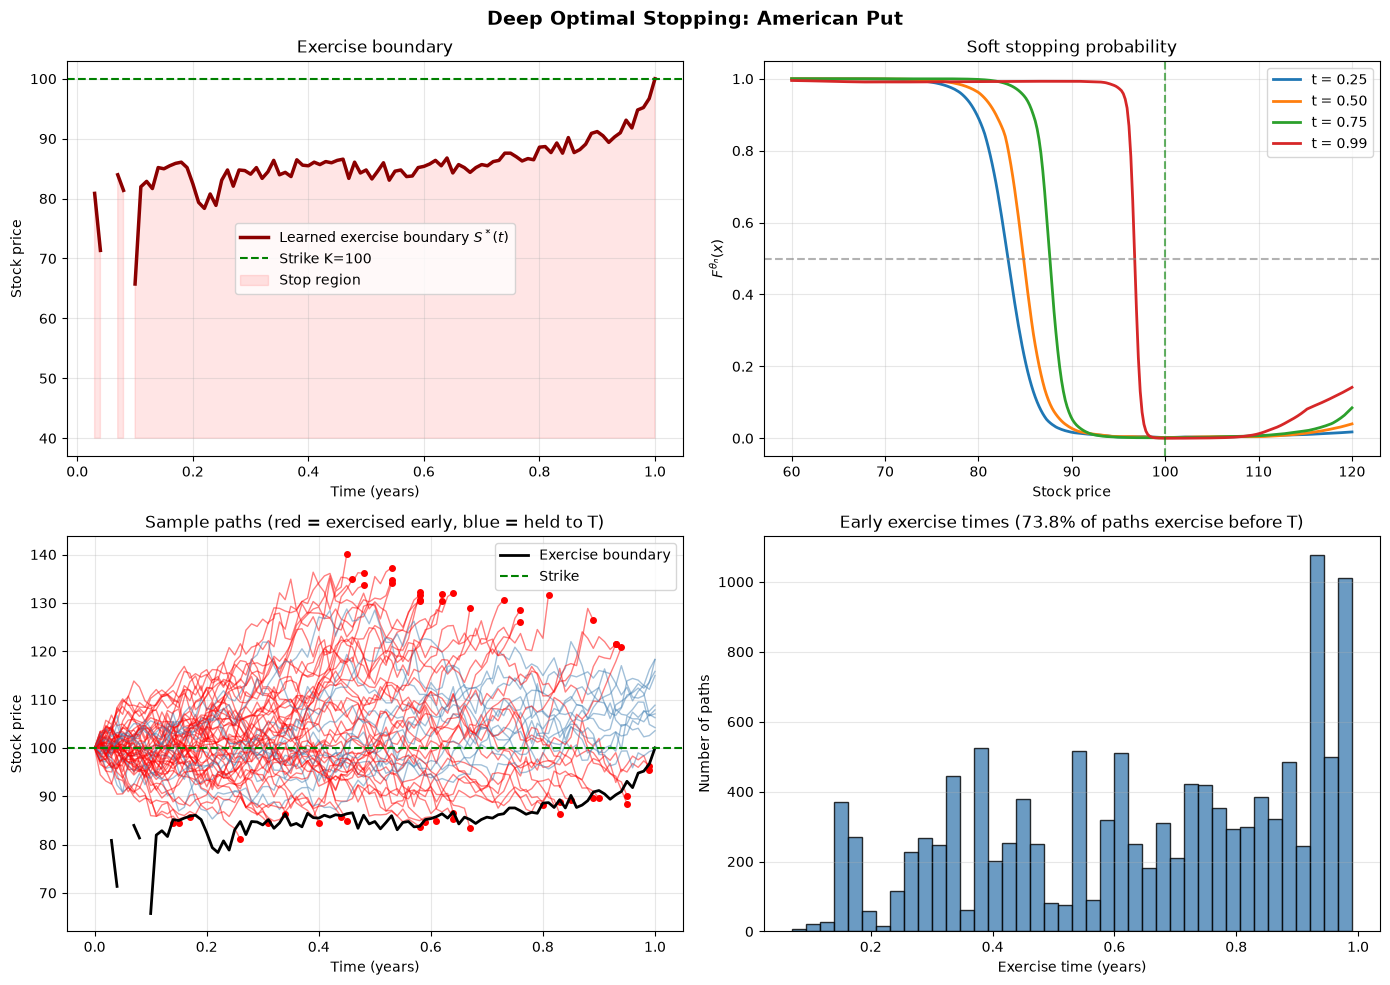

In [120]:
# Benchmarks: CRR binomial tree (Bermudan with the same N dates, and American) and Longstaff-Schwartz
def binomial_put(S0, K, r, sigma, T, n_tree, exercise_every=1):
    dt_ = T / n_tree
    u = math.exp(sigma * math.sqrt(dt_))
    d = 1 / u
    p = (math.exp(r * dt_) - d) / (u - d)
    disc = math.exp(-r * dt_)
    s = S0 * u ** np.arange(n_tree, -1, -1) * d ** np.arange(0, n_tree + 1)
    v = np.maximum(K - s, 0)
    for i in range(n_tree - 1, -1, -1):
        s = S0 * u ** np.arange(i, -1, -1) * d ** np.arange(0, i + 1)
        v = disc * (p * v[:-1] + (1 - p) * v[1:])
        if i % exercise_every == 0:
            v = np.maximum(v, K - s)
    return v[0]


def longstaff_schwartz_put(paths, K, r, dt_, degree=3):
    """Original LSM: regress discounted realised cash flows on a polynomial basis, ITM paths only."""
    n_dates = paths.shape[1] - 1
    cash = np.maximum(K - paths[:, -1], 0)
    for n in range(n_dates - 1, 0, -1):
        cash *= math.exp(-r * dt_)
        s = paths[:, n]
        exercise = np.maximum(K - s, 0)
        itm = exercise > 0
        if itm.sum() > degree:
            coef = np.polyfit(s[itm], cash[itm], degree)
            stop = itm.copy()
            stop[itm] = exercise[itm] > np.polyval(coef, s[itm])
            cash[stop] = exercise[stop]
    return math.exp(-r * dt_) * cash.mean()


bermudan_ref = binomial_put(S0, K, r, sigma, T, N * 20, exercise_every=20)
american_ref = binomial_put(S0, K, r, sigma, T, 5000)
lsm_price = longstaff_schwartz_put(dos.simulate(2**17)[:, :, 0].numpy(), K, r, dt_ex)

print("=" * 60)
print(f"{'Method':<36}{'Price':>10}")
print("-" * 60)
print(f"{'Deep OS lower bound L_hat':<36}{result['lower']:>10.4f}")
print(f"{'Deep OS upper bound U_hat':<36}{result['upper']:>10.4f}")
print(f"{'Deep OS point estimate':<36}{result['point']:>10.4f}")
print(f"{'Deep OS 95% CI':<36}  [{result['ci'][0]:.4f}, {result['ci'][1]:.4f}]")
print(f"{'Longstaff-Schwartz':<36}{lsm_price:>10.4f}")
print(f"{f'Binomial Bermudan ({N} dates)':<36}{bermudan_ref:>10.4f}")
print(f"{'Binomial American':<36}{american_ref:>10.4f}")
print("=" * 60)

# Learned policy on fresh paths
test_paths = dos.simulate(2**14)
tau, _ = dos.stopping_times(test_paths)
tau = tau.numpy().astype(int)
t_grid = np.linspace(0, T, N + 1)

# Exercise boundary: largest S at which f^{theta_n} says stop
s_grid = torch.linspace(40, K, 600).unsqueeze(1)
boundary = np.full(N + 1, np.nan)
for n in range(1, N):
    stop = dos.stop_decision(n, s_grid).numpy()
    if stop.any():
        boundary[n] = s_grid[stop, 0].max().item()
boundary[N] = K

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Deep Optimal Stopping: American Put', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.plot(t_grid, boundary, color='darkred', linewidth=2.5, label='Learned exercise boundary $S^*(t)$')
ax.axhline(K, color='green', linestyle='--', label=f'Strike K={K:g}')
ax.fill_between(t_grid, 40, boundary, color='red', alpha=0.1, label='Stop region')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Stock price')
ax.set_title('Exercise boundary')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
s_plot = torch.linspace(60, 120, 300).unsqueeze(1)
for n in [N // 4, N // 2, 3 * N // 4, N - 1]:
    ax.plot(s_plot.squeeze().numpy(), dos.exercise_probability(n, s_plot).numpy(),
            linewidth=2, label=f't = {n * dt_ex:.2f}')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.axvline(K, color='green', linestyle='--', alpha=0.6)
ax.set_xlabel('Stock price')
ax.set_ylabel(r'$F^{\theta_n}(x)$')
ax.set_title('Soft stopping probability')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
paths_np = test_paths[:60, :, 0].numpy()
for k in range(paths_np.shape[0]):
    tk = tau[k]
    early = tk < N
    ax.plot(t_grid[:tk + 1], paths_np[k, :tk + 1], color='red' if early else 'steelblue',
            alpha=0.5, linewidth=1)
    if early:
        ax.plot(t_grid[tk], paths_np[k, tk], 'o', color='red', markersize=4)
ax.plot(t_grid, boundary, color='black', linewidth=2, label='Exercise boundary')
ax.axhline(K, color='green', linestyle='--', label='Strike')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Stock price')
ax.set_title('Sample paths (red = exercised early, blue = held to T)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
early_mask = tau < N
ax.hist(tau[early_mask] * dt_ex, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Exercise time (years)')
ax.set_ylabel('Number of paths')
ax.set_title(f'Early exercise times ({early_mask.mean():.1%} of paths exercise before T)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()